# **DLS Backtest**

In [75]:
# general 
import os
import sys 
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
# .py 
root = '/Users/amjadsaidam/Desktop/Quant stuff /Algorithmic Strategies /coinbase_trading_bot'
root_path = os.path.abspath(root)
importing_folders = ['data_loaders', 'models']
import_paths = [os.path.join(root, import_path) for import_path in importing_folders]
for p in ([root] + import_paths): 
    if p not in sys.path:
        sys.path.insert(0, p)
from data_loaders.features_and_labels import rolling_volatility
import models.lstm_trading as lstm 

## **Data** 

In [76]:
# fetch data 
data_universe = {}
data_path = os.path.join(root, 'data')

for f in Path(data_path).iterdir():
    # print path
    print(f)
    # data  
    data = pd.read_csv(f, index_col = 'Unnamed: 0')
    data.set_index(
        pd.DatetimeIndex(data.index), inplace = True
    )
    # append 
    symbol = str(f).split('data/')[-1].split('_')[0]
    data_universe[symbol] = data

/Users/amjadsaidam/Desktop/Quant stuff /Algorithmic Strategies /coinbase_trading_bot/data/USDT-GBP_2023-01-01_2026-01-01.csv
/Users/amjadsaidam/Desktop/Quant stuff /Algorithmic Strategies /coinbase_trading_bot/data/BTC-GBP_2023-01-01_2026-01-01.csv
/Users/amjadsaidam/Desktop/Quant stuff /Algorithmic Strategies /coinbase_trading_bot/data/ETH-GBP_2023-01-01_2026-01-01.csv
/Users/amjadsaidam/Desktop/Quant stuff /Algorithmic Strategies /coinbase_trading_bot/data/LINK-GBP_2023-01-01_2026-01-01.csv
/Users/amjadsaidam/Desktop/Quant stuff /Algorithmic Strategies /coinbase_trading_bot/data/SOL-GBP_2023-01-01_2026-01-01.csv


In [77]:
# join data 
# get lowest common start index
symbol_start = {s: data.index[0] for s, data in data_universe.items()}
max_key = max(symbol_start, key = symbol_start.get) # analgous to np.argmax/argmin

base_data: pd.DataFrame = data_universe[max_key]
drop_index = max(np.isnan(base_data).sum())

# join from lowest common index 
for s, data in data_universe.items():
    data_universe[s] = data.iloc[drop_index: , :]

USDT-GBP
dim: (315649, 5)
Column NA counts:
low       0
high      0
open      0
close     0
volume    0
dtype: int64



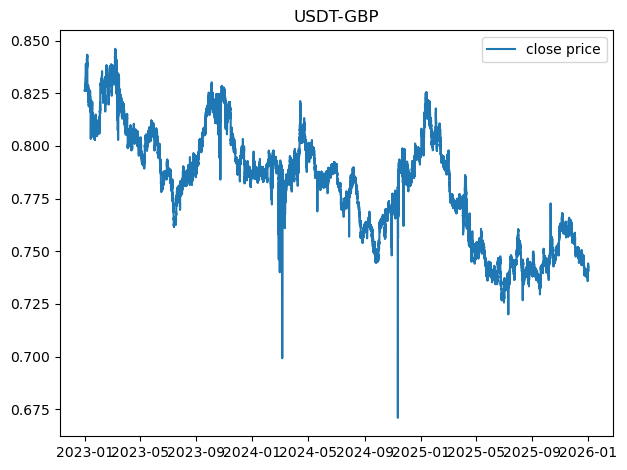


BTC-GBP
dim: (315649, 5)
Column NA counts:
low       0
high      0
open      0
close     0
volume    0
dtype: int64



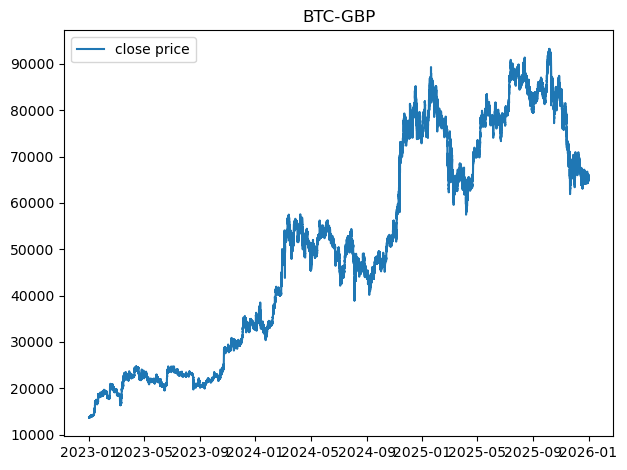


ETH-GBP
dim: (315649, 5)
Column NA counts:
low       0
high      0
open      0
close     0
volume    0
dtype: int64



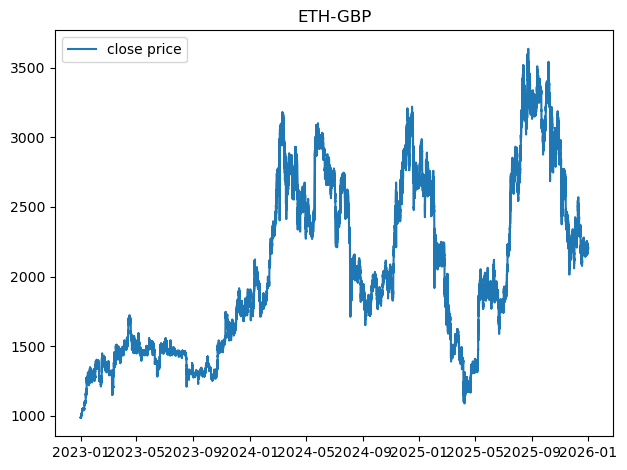


LINK-GBP
dim: (315649, 5)
Column NA counts:
low       0
high      0
open      0
close     0
volume    0
dtype: int64



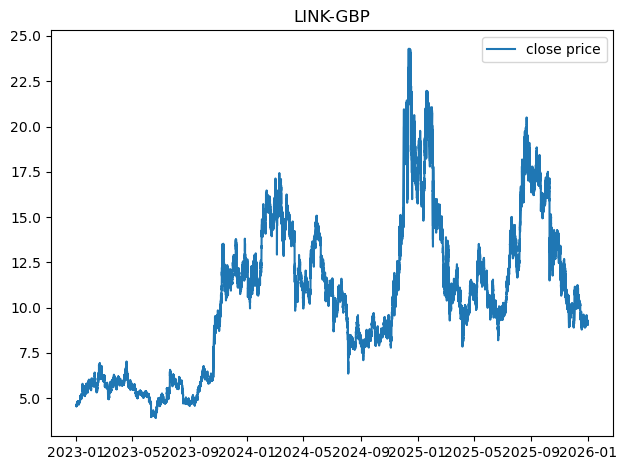


SOL-GBP
dim: (315649, 5)
Column NA counts:
low       0
high      0
open      0
close     0
volume    0
dtype: int64



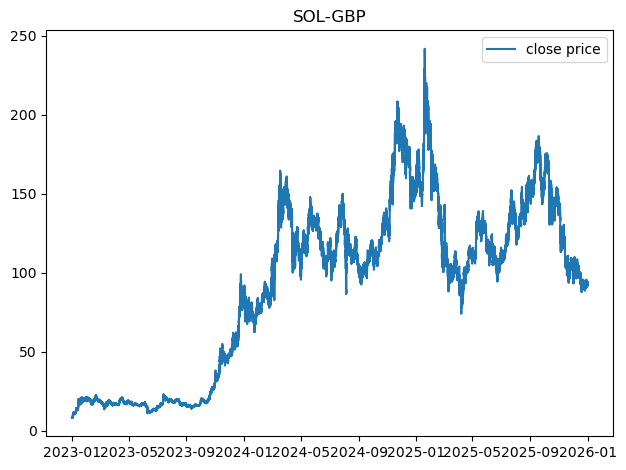

In [78]:
for s, data in data_universe.items():
    # summary 
    print(s)
    print('dim:', data.shape)
    print('Column NA counts:')
    print(np.isnan(data_universe['SOL-GBP']).sum())
    print()

    # plot 
    plt.plot(data['close'], label = 'close price')
    plt.title(s)
    plt.legend()
    plt.tight_layout()
    plt.show()
    print()

## **WFA** 

### **EDA**

total IS/OOS folds: 41
full OOS non zero predictions: 1.0
average IS train set loss: -0.28366712632946156
average IS eval set loss: -0.15857325915244447


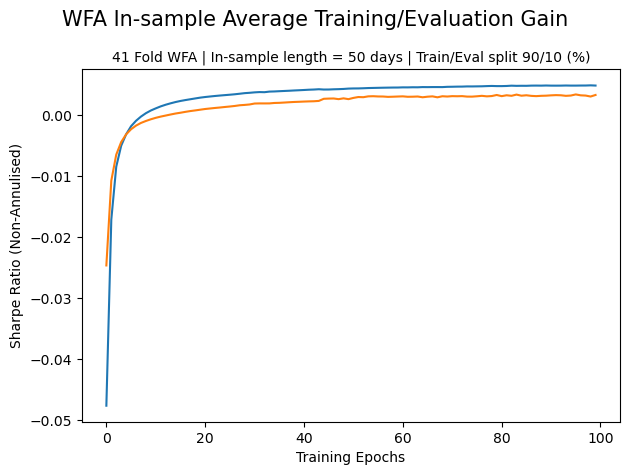

avergae asset weights: [0.19972166 0.20374696 0.17043914 0.23363866 0.14817783]


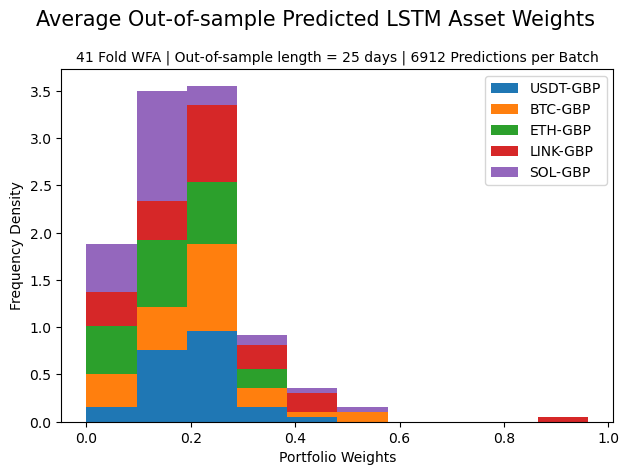

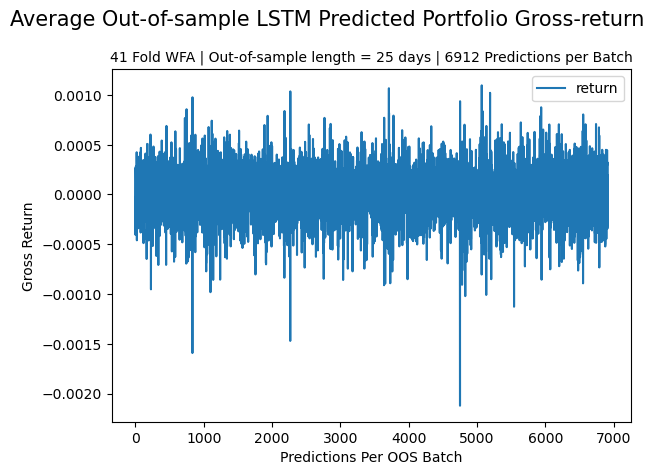

In [266]:
root_path_wfa = '/Users/amjadsaidam/Desktop/Quant stuff /Algorithmic Strategies /coinbase_trading_bot/walk_forward_analysis/wfa.pkl'
with open(root_path_wfa, mode = 'rb') as f: 
    wfa = pickle.load(f)

# wfa payloads 
wfa_regime = np.array(wfa['regime_mask'])
wfa_w = np.array(wfa['gated_weights'])
wfa_rt = np.array(wfa['gated_returns'])
wfa_vol = wfa['vol_scale']
fold_train_eval_loss = {}
for fold in range(len(wfa_w)):
    fold_train_eval_loss[fold] = {
        'train_losses': wfa['model_train_loss_container'][0], 
        'eval_looses': wfa['model_eval_loss_container'][0]
    }

# metadata 
print('total IS/OOS folds:', len(wfa_w))
# non zero values
rt = np.array(wfa_rt)
rt_non_zero = ~np.isnan(wfa_rt)
rt_non_zero = rt_non_zero.all(axis = 1)
rt_non_zero_idx = np.argwhere(rt_non_zero)
print('full OOS non zero predictions:', len(rt_non_zero_idx) / len(wfa_rt))
print('average IS train set loss:', np.mean([sum(v) for v in wfa['model_train_loss_container']]))
print('average IS eval set loss:', np.mean([sum(v) for v in wfa['model_eval_loss_container']]))

# eval and test losses 
avg_is_train_looses = np.array(wfa['model_train_loss_container']).mean(axis = 0) * -1
avg_is_eval_loosses = np.array(wfa['model_eval_loss_container']).mean(axis = 0) * -1
plt.plot(avg_is_train_looses, label = 'train set')
plt.plot(avg_is_eval_loosses, label = 'eval set');
plt.suptitle('WFA In-sample Average Training/Evaluation Gain', fontsize = 15)
plt.title('41 Fold WFA | In-sample length = 50 days | Train/Eval split 90/10 (%)', fontsize = 10)
plt.xlabel('Training Epochs')
plt.ylabel('Sharpe Ratio (Non-Annulised)')
plt.tight_layout()
plt.show();

# portdolio weights 
full_wfa_w = wfa_w.reshape(-1, wfa_w.shape[-1])
print('avergae asset weights:', full_wfa_w.mean(axis = 0))
oos_avg_w = wfa_w.mean(axis = 1)
plt.hist(oos_avg_w, density = True, stacked = True, label = data_universe.keys())
plt.suptitle('Average Out-of-sample Predicted LSTM Asset Weights', fontsize = 15)
plt.title(f'41 Fold WFA | Out-of-sample length = 25 days | {wfa_w.shape[1]} Predictions per Batch', fontsize = 10)
plt.xlabel('Portfolio Weights')
plt.ylabel('Frequency Density')
plt.legend()
plt.tight_layout()
plt.show();

# portfolio returns 
avg_wfa_pred_rt = wfa_rt.mean(axis = 0)
plt.plot(avg_wfa_pred_rt, label = 'return')
plt.suptitle('Average Out-of-sample LSTM Predicted Portfolio Gross-return', fontsize = 15)
plt.title(f'41 Fold WFA | Out-of-sample length = 25 days | {wfa_w.shape[1]} Predictions per Batch', fontsize = 10)
plt.xlabel('Predictions Per OOS Batch')
plt.ylabel('Gross Return')
plt.legend()
plt.tight_layout()
plt.show();

### **WFA OOS Backtest Performance**

In [267]:
def returns(asset: pd.DataFrame) -> pd.Series: 
    """log returns"""
    asset_close = asset['close']
    return np.log(asset_close / asset_close.shift(periods = 1)).fillna(0.0)

def rolling_corr(benchmark: pd.DataFrame,
                 asset: pd.DataFrame, 
                 window: int = 200):
    """rolling correlation"""
    bench_rt = returns(benchmark)
    asset_rt = returns(asset)

    # rolling corr (Cov_xy / std_x * std_y)
    # rolling cov (Ex * Ey - Exy)
    xy = bench_rt * asset_rt
    e_xy =  xy.rolling(window).mean()
    e_x = bench_rt.rolling(window).mean()
    e_y = asset_rt.rolling(window).mean()
    cov_xy = e_xy - e_x * e_y
    # rolling std 
    std_x = bench_rt.rolling(window).std()
    std_y = asset_rt.rolling(window).std()

    return np.where(
        (std_x * std_y) > 0, cov_xy / (std_x * std_y), 0.0
    )

def rolling_expected_pos_return(asset: pd.DataFrame, 
                                window: int = 200):
    """average rolling asset return"""
    asset_rt = returns(asset)
    exp = asset_rt.rolling(window).mean().fillna(0.0)
    return np.where(exp < 0, True, False)

In [268]:
a = wfa_rt[0]
a[a > 0.01] - 0.01

array([0.00299908, 0.00040416, 0.00280326, 0.0017338 , 0.00249556],
      dtype=float32)

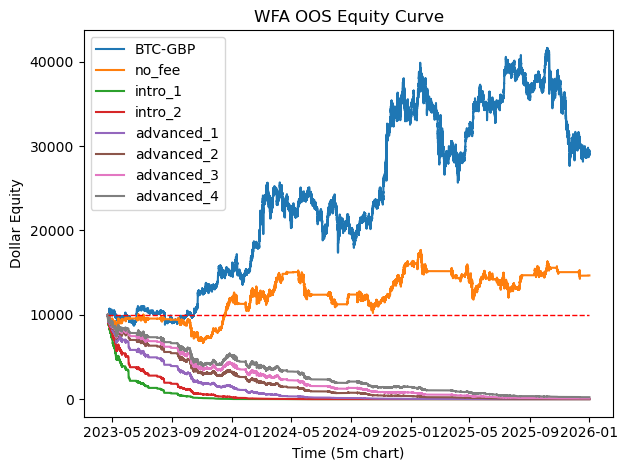

In [ ]:
# starting account balance
initial_wealth = 1e4

# fees
fees = {
    'no_fee': 0, 
    'intro_1': 0.012, 
    'intro_2': 0.0075, 
    'advanced_1': 0.0040,
    'advanced_2': 0.0025, 
    'advanced_3': 0.0020, 
    'advanced_4': 0.0016, 
}

# benchmark 
bench = 'BTC-GBP'
oos_len = wfa_w[0].shape[0] * len(wfa_w)
oos_bench = data_universe[bench][-oos_len: ]['close']
oos_bench_rt = np.log(oos_bench / oos_bench.shift(periods = 1, axis = 0)).fillna(0)
oos_bench_eq = initial_wealth * np.exp(np.cumsum(oos_bench_rt))
oos_time = pd.DatetimeIndex(oos_bench_eq.index)

# equity 
def backtest(returns: np.ndarray, 
             weights: np.ndarray, 
             fee: float | None = None,  
             initial_wealth: float = 1.0):
    """portfolio (adjusted) equity curve from returns"""
    all_rt = returns.flatten()

    # OOS regime 
    sma_window = int(60 / 5 * 24)
    sma_bench = oos_bench.rolling(window = sma_window).mean().to_numpy()
    trend_mask = oos_bench < sma_bench
    full_mask = wfa_regime.reshape(-1, ) | trend_mask # dont trade cases

    # re-mask weights and returns 
    weights = weights.copy()
    weights_org_shape = weights.shape
    weights = weights.reshape(-1, 5)
    weights[full_mask] = 0.0
    weights = weights.reshape(weights_org_shape)
    all_rt = np.where(full_mask, 0.0, all_rt)
    
    # weight rebals
    wfa_w_diffs = []
    w_prev_end = None # guard against full fees per wfa oos boundary
    for w_batch in weights: 
        w_last = np.zeros_like(w_batch)
        w_last[1: , :] = w_batch[0: -1, :]
        # set first value current wfa oos weights to last wfa oos batch prediction
        if w_prev_end is not None: 
            w_last[0, :] = w_prev_end
        wfa_w_diffs.append(
            w_batch - w_last
        )
        w_prev_end = w_batch[-1, :]
    turnover = np.abs(np.array(wfa_w_diffs)).sum(axis = 2).flatten()

    # fees
    if fee is not None: 
        volume_based_fee = turnover * fee
        # global fee
        all_rt = np.where(full_mask, 0.0, all_rt - volume_based_fee)
        # fee at boundaries 
        past_regime = np.concat([[False], full_mask[: -1]])
        regime_boundaries = full_mask & ~past_regime
        all_rt = np.where(regime_boundaries, -volume_based_fee, all_rt)
    eq = initial_wealth * np.exp(np.cumsum(all_rt))

    # previous equity 
    total_fees_paid = 0.0
    if fee is not None:
        eq_prev = np.concatenate(([initial_wealth], eq[:-1]))
        fees_paid = eq_prev * turnover * fee # fees as fraction of future equity values 
        total_fees_paid = fees_paid.sum()

    return {
        'equity':  eq, 
        'weights': weights,
        'fees': total_fees_paid,
        'turnover': turnover
    }

# equity dicts 
wfa_eq = {}
for tier, fee in fees.items(): 
    eq_sim = backtest(returns = wfa_rt, 
                      weights = wfa_w, 
                      fee = fee, 
                      initial_wealth = initial_wealth)
    wfa_eq[tier] = eq_sim

# plot equity
plt.plot(oos_time, oos_bench_eq, linestyle = '-')
plt.plot(oos_time, wfa_eq['no_fee']['equity'])
plt.plot(oos_time, wfa_eq['intro_1']['equity'])
plt.plot(oos_time, wfa_eq['intro_2']['equity'])
plt.plot(oos_time, wfa_eq['advanced_1']['equity'])
plt.plot(oos_time, wfa_eq['advanced_2']['equity'])
plt.plot(oos_time, wfa_eq['advanced_3']['equity'])
plt.plot(oos_time, wfa_eq['advanced_4']['equity'])
plt.hlines(initial_wealth, oos_time[0], oos_time[-1], color = 'red', linestyle = '--', linewidth = 1)
plt.title('WFA OOS Equity Curve')
plt.xlabel('Time (5m chart)')
plt.ylabel('Dollar Equity')
plt.legend([bench] + list(fees.keys()))
plt.tight_layout()
plt.show();

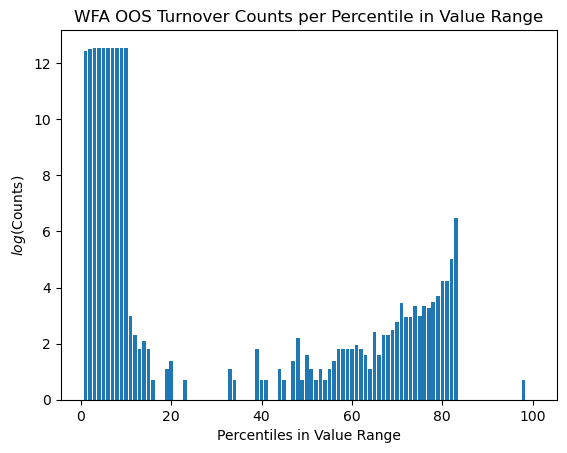

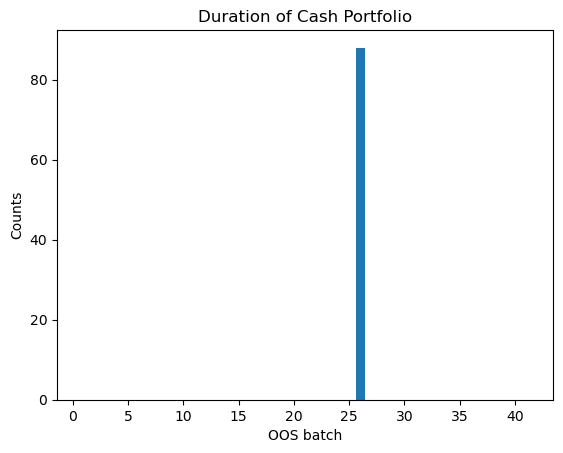

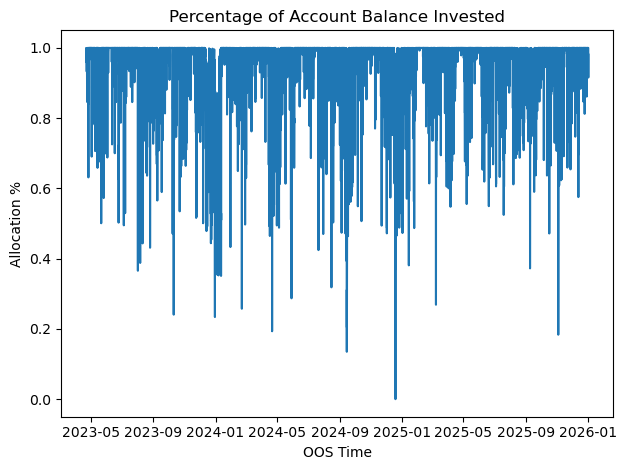

In [272]:
# turnover percentile counts plot
turnover = wfa_eq['advanced_1']['turnover']
turnover_decile_counts = {}

percentiles = []
max_turnover = turnover.max()
for q in range(1, 101, 1):
    p_high = max_turnover * q / 100
    decile_low_counts = 0
    if q > 10:
        p_low = percentiles[-1]
        decile_low_counts = len(turnover[turnover <= p_low])
    decile_counts = len(turnover[turnover <= p_high]) - decile_low_counts

    percentiles.append(p_high.item())

    turnover_decile_counts[q] = np.log(decile_counts) if (decile_counts > 0) else 0
    
plt.bar(turnover_decile_counts.keys(), turnover_decile_counts.values())
plt.title('WFA OOS Turnover Counts per Percentile in Value Range')
plt.xlabel('Percentiles in Value Range')
plt.ylabel(r'$log$(Counts)')
plt.show()

# cash portfolio duration in each OOS batch
num_full_turnovers_per_batch = {}
for batch, w_batch in enumerate(wfa_w): 
    row_sums = w_batch.sum(axis = 1)
    num_full_turnovers_per_batch[batch + 1] = row_sums[row_sums == 0].shape[0]

plt.bar(num_full_turnovers_per_batch.keys(), num_full_turnovers_per_batch.values())
plt.title('Duration of Cash Portfolio')
plt.xlabel('OOS batch')
plt.ylabel('Counts')
plt.show()

# allocation over time 
full_oos_w = wfa_w.reshape(-1, 5)
full_oos_w = full_oos_w.sum(axis = 1)
plt.plot(oos_time, full_oos_w)
plt.title('Percentage of Account Balance Invested')
plt.xlabel('OOS Time')
plt.ylabel('Allocation %')
plt.tight_layout()
plt.show(); 